In [2]:

from torchvision import datasets

data_dir = "/content/cifar10_data"

cifar_train = datasets.CIFAR10(
    root=data_dir,
    train=True,
    download=True
)

cifar_test = datasets.CIFAR10(
    root=data_dir,
    train=False,
    download=True
)

print("Dataset downloaded!")
print("Training images:", len(cifar_train))
print("Testing images:", len(cifar_test))
print("Available classes:", cifar_train.classes)


100%|██████████| 170M/170M [01:36<00:00, 1.77MB/s]


Dataset downloaded!
Training images: 50000
Testing images: 10000
Available classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform
        self.indices = [
            i for i, label in enumerate(base_dataset.targets)
            if label in [3, 5]
        ]
        self.classes = ["cat", "dog"]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        actual_index = self.indices[index]
        image, original_label = self.base_dataset[actual_index]

        label = 0 if original_label == 3 else 1

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:

from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = CustomImageDataset(
    cifar_train, transform=transform
)
test_dataset = CustomImageDataset(
    cifar_test, transform=transform
)

train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True,
    num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))


Classes: ['cat', 'dog']
Training images: 10000
Testing images: 2000


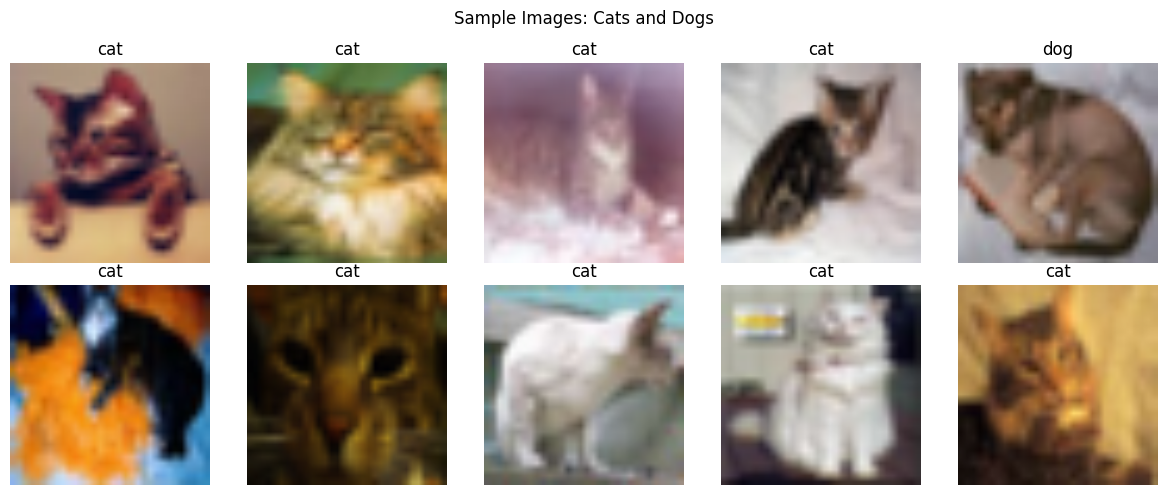

In [5]:

import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)

    ax.imshow(img)
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.suptitle("Sample Images: Cats and Dogs")
plt.tight_layout()
plt.show()


In [6]:

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
    VGG16_Weights,
    DenseNet121_Weights
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

def create_model(model_name, num_classes=2):
    if model_name == "ResNet18":
        model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        classifier = model.fc

    elif model_name == "MobileNetV3":
        model = models.mobilenet_v3_small(
            weights=MobileNet_V3_Small_Weights.DEFAULT
        )
        model.classifier[3] = nn.Linear(
            model.classifier[3].in_features, num_classes
        )
        classifier = model.classifier[3]

    elif model_name == "EfficientNetB0":
        model = models.efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features, num_classes
        )
        classifier = model.classifier[1]

    elif model_name == "VGG16":
        model = models.vgg16(weights=VGG16_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features, num_classes
        )
        classifier = model.classifier[6]

    elif model_name == "DenseNet121":
        model = models.densenet121(
            weights=DenseNet121_Weights.DEFAULT
        )
        model.classifier = nn.Linear(
            model.classifier.in_features, num_classes
        )
        classifier = model.classifier

    # Freeze pretrained parameters
    for param in model.parameters():
        param.requires_grad = False

    # Train only the new classification layer
    for param in classifier.parameters():
        param.requires_grad = True

    return model.to(device)

print("Model function is ready!")


Model function is ready!


In [7]:

import torch.optim as optim
from tqdm.auto import tqdm

def train_model(model, train_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001
    )

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs}"
        ):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")

    return model


In [8]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    return {
        "Accuracy": accuracy_score(all_labels, all_predictions),
        "Precision": precision_score(
            all_labels, all_predictions,
            average="macro", zero_division=0
        ),
        "Recall": recall_score(
            all_labels, all_predictions,
            average="macro", zero_division=0
        ),
        "F1-Score": f1_score(
            all_labels, all_predictions,
            average="macro", zero_division=0
        ),
        "Labels": all_labels,
        "Predictions": all_predictions
    }


In [9]:

model_names = [
    "ResNet18",
    "MobileNetV3",
    "EfficientNetB0",
    "VGG16",
    "DenseNet121"
]

results = []
trained_models = {}
evaluation_outputs = {}

for name in model_names:
    print(f"\n{'='*40}")
    print(f"Training {name}")
    print(f"{'='*40}")

    model = create_model(name, num_classes=2)

    model = train_model(
        model,
        train_loader,
        epochs=5
    )

    metrics = evaluate_model(model, test_loader)

    trained_models[name] = model
    evaluation_outputs[name] = metrics

    results.append({
        "Model": name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1-Score": metrics["F1-Score"]
    })

    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall: {metrics['Recall']:.4f}")
    print(f"F1-Score: {metrics['F1-Score']:.4f}")

print("\nAll models evaluated!")



Training ResNet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Epoch 1/5:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1: Loss = 0.4532


Epoch 2/5:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 4: Loss = 0.3599


Epoch 5/5:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 5: Loss = 0.3569


  0%|          | 0/63 [00:00<?, ?it/s]

Accuracy: 0.8460
Precision: 0.8463
Recall: 0.8460
F1-Score: 0.8460

All models evaluated!


In [10]:

import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1-Score
0,DenseNet121,0.8460,0.8463,0.8460,0.8460
1,MobileNetV3,0.8385,0.8385,0.8385,0.8385
2,EfficientNetB0,0.8350,0.8354,0.8350,0.8349
3,VGG16,0.8320,0.8412,0.8320,0.8309
4,ResNet18,0.8275,0.8279,0.8275,0.8274


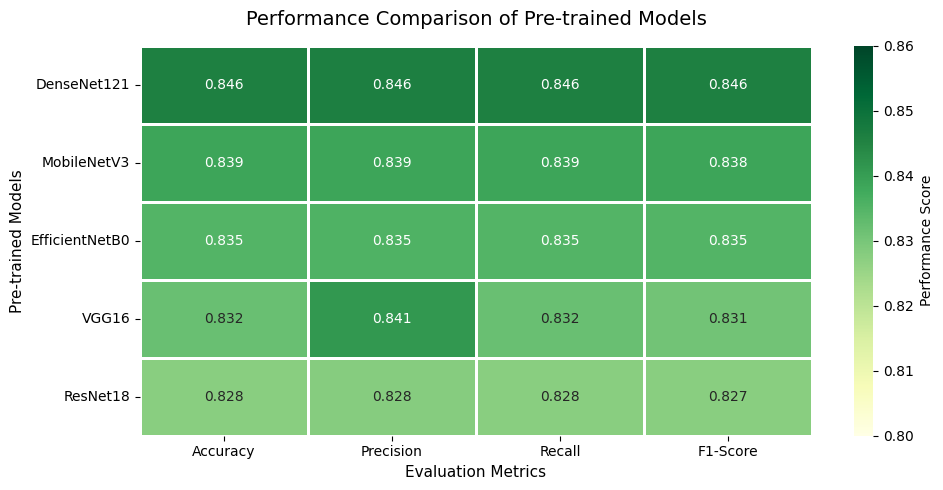

In [12]:

import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
heatmap_data = results_df.set_index("Model")[metrics]

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGn",
    vmin=0.80,
    vmax=0.86,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Performance Score"}
)

plt.title(
    "Performance Comparison of Pre-trained Models",
    fontsize=14,
    pad=15
)
plt.xlabel("Evaluation Metrics", fontsize=11)
plt.ylabel("Pre-trained Models", fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


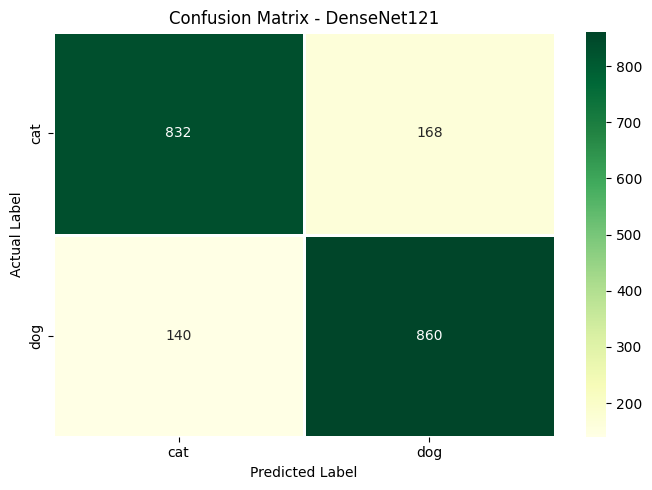

              precision    recall  f1-score   support

         cat       0.86      0.83      0.84      1000
         dog       0.84      0.86      0.85      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

best_model_name = "DenseNet121"
best_model = trained_models[best_model_name]

# Get predictions
best_metrics = evaluation_outputs[best_model_name]

y_true = best_metrics["Labels"]
y_pred = best_metrics["Predictions"]

# Define class names from the dataset
class_names = train_dataset.classes

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="white"
)

plt.title("Confusion Matrix - DenseNet121")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

### Analysis

The experiment evaluated five pre-trained convolutional neural network models for cat and dog image classification using accuracy, precision, recall, and F1-score. Based on the results, DenseNet121 achieved the highest overall performance, with an accuracy, precision, recall, and F1-score of 84.6%. MobileNetV3 followed with an accuracy of 83.9% and an F1-score of 83.8%, while EfficientNetB0 achieved an accuracy and F1-score of 83.5%. VGG16 and ResNet18 obtained accuracy scores of 83.2% and 82.8%, respectively.

DenseNet121 demonstrated the strongest classification performance among the evaluated models. Its dense connectivity allows features to be reused across network layers, which may have contributed to its performance. MobileNetV3 also achieved competitive results, highlighting the potential of lightweight architectures for image classification. The differences in performance may be attributed to model architecture, feature extraction capabilities, and the characteristics of the dataset.

### Conclusion

The laboratory exercise successfully demonstrated the use of transfer learning and model evaluation using five pre-trained convolutional neural networks in PyTorch. Among the evaluated models, DenseNet121 achieved the highest accuracy and F1-score of 84.6%, making it the best-performing model in this experiment. The results indicate that model architecture can influence classification performance, even when models use the same dataset and training conditions.

Overall, the experiment showed that pre-trained models can be adapted to a custom image classification task through transfer learning. DenseNet121 provided the strongest classification results in this evaluation, although further testing with larger and more diverse datasets, additional training, and fine-tuning could provide a more comprehensive comparison.